GRU Model

ImportS

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

Load Data

In [ ]:
df = pd.read_csv('processed_stock_data.csv')

print(df.head())
print(df.columns)

         Date        Open        High         Low       Close    Volume  \
0  2021-06-07  123.097765  123.244114  121.790398  122.834343  71057600   
1  2021-06-08  123.517287  125.332004  123.136784  123.653877  74403800   
2  2021-06-09  124.112432  124.639284  123.439231  124.034378  56877900   
3  2021-06-10  123.927045  125.068561  122.873349  123.039207  71186400   
4  2021-06-11  123.448976  124.336821  123.029446  124.249008  53522400   

  Ticker      SMA_20      SMA_50     RSI_14      MACD  MACD_Signal  \
0   AAPL  122.537245  125.013458  48.785329 -0.852041    -0.870258   
1   AAPL  122.531879  125.125376  56.450591 -0.698815    -0.835969   
2   AAPL  122.591393  125.241397  58.198951 -0.540448    -0.776865   
3   AAPL  122.754326  125.366540  45.481916 -0.489600    -0.719412   
4   AAPL  122.870428  125.472049  57.594902 -0.347673    -0.645064   

   Bollinger_Upper  Bollinger_Lower  Target_Direction  
0       125.042355       120.032135                 1  
1       125.0263

Select Features

In [5]:
features = df[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()

Normalize Data

In [6]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(features)

Create Sequences

We use past 10 days → predict next day Close price

In [7]:
def create_sequences(data, seq_length=10):
    X, y = [], []

    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length][3])  # Close price

    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, seq_length=10)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8432, 10, 5)
y shape: (8432,)


Train & Test

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

Build GRU

In [ ]:
model = Sequential()

model.add(GRU(64, return_sequences=False,
              input_shape=(X_train.shape[1], X_train.shape[2])))

model.add(Dropout(0.5))
model.add(Dense(1))  

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        13,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,697 (53.50 KB)

 Trainable params: 13,697 (53.50 KB)

 Non-trainable params: 0 (0.00 B)

Train Model

In [10]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0070 - val_loss: 3.2292e-04
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0023 - val_loss: 2.4303e-04
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0019 - val_loss: 2.5259e-04
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0017 - val_loss: 2.2173e-04
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0013 - val_loss: 2.3429e-04
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0013 - val_loss: 2.6921e-04
Epoch 7/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0011 - val_loss: 2.1803e-04
Epoch 8/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0011 - val_loss: 2.3020e-04
Epoch 9/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 9.9841e-04 - val_loss: 2.0309e-04
Epoch 10/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 9.0636e-04 - val_loss: 2.2423e-04


Predictions

In [11]:
y_pred = model.predict(X_test)

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


Convert Back to Real Prices

In [ ]:
dummy = np.zeros((len(y_pred), 5))
dummy[:, 3] = y_pred.flatten()

y_pred_real = scaler.inverse_transform(dummy)[:, 3]

dummy[:, 3] = y_test.flatten()
y_test_real = scaler.inverse_transform(dummy)[:, 3]

Results

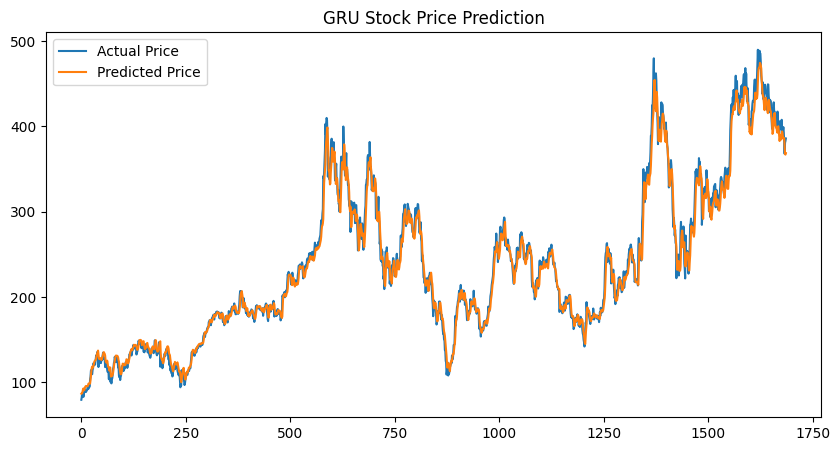

In [13]:
plt.figure(figsize=(10,5))
plt.plot(y_test_real, label='Actual Price')
plt.plot(y_pred_real, label='Predicted Price')
plt.legend()
plt.title("GRU Stock Price Prediction")
plt.show()

BERT Model - Financial Sentiment Analysis
**Dataset:** Financial PhraseBank

Trains a BERT model to classify financial text into:
- Positive
- Negative
- Neutral


Import

In [14]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset

 Load Dataset

In [15]:
file_path = "Sentences_AllAgree.txt"

texts = []
labels = []

with open(file_path, 'r', encoding='latin-1') as f:
    for line in f:
        text, label = line.strip().rsplit('@', 1)
        texts.append(text)
        labels.append(label)

df = pd.DataFrame({'text': texts, 'label': labels})
print(df.head())


                                                text     label
0  According to Gran , the company has no plans t...   neutral
1  For the last quarter of 2010 , Componenta 's n...  positive
2  In the third quarter of 2010 , net sales incre...  positive
3  Operating profit rose to EUR 13.1 mn from EUR ...  positive
4  Operating profit totalled EUR 21.1 mn , up fro...  positive


Encode Labels

In [16]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])
print("Label Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))


Label Mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


Train-Test

In [17]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42
)


Tokenization using BERT


In [18]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Create Custom Dataset Class

In [19]:
class FinancialDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = FinancialDataset(train_encodings, train_labels)
val_dataset = FinancialDataset(val_encodings, val_labels)

Load Pretrained BERT Model

In [20]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Define Training Arguments

In [21]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    do_eval=True
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [22]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

Train The Model

In [23]:
trainer.train()


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
10,1.130572
20,1.021671
30,0.902195
40,0.828763
50,0.710250
60,0.611285
70,0.590353
80,0.734279
90,0.450420
100,0.451281


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=681, training_loss=0.21297796118406856, metrics={'train_runtime': 5549.1073, 'train_samples_per_second': 0.979, 'train_steps_per_second': 0.123, 'total_flos': 259654401292986.0, 'train_loss': 0.21297796118406856, 'epoch': 3.0})

Evaluate The Model

In [24]:
results = trainer.evaluate()
print("Evaluation Results:", results)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Evaluation Results: {'eval_loss': 0.08796767890453339, 'eval_runtime': 183.216, 'eval_samples_per_second': 2.472, 'eval_steps_per_second': 0.311, 'epoch': 3.0}


Prediction

In [25]:
def predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    outputs = model(**inputs)
    logits = outputs.logits
    predicted_class_id = torch.argmax(logits, dim=1).item()
    return le.inverse_transform([predicted_class_id])[0]

Test Predictions

In [26]:
print(predict("The company profits increased significantly"))
print(predict("The firm reported heavy losses"))


positive
negative
